<a href="https://colab.research.google.com/github/Cyber-GenAI/agent_attack_nlp/blob/main/cerberus_final_unified_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERBERUS — Final Unified Evaluation (Phase 4 + Phase 5.1 Merged)

**Single source of truth for the paper’s experimental section.**  
This notebook merges Phase-4 calibration/diagnostics with Phase-5.1 end-to-end evaluation,  
applies every correctness fix identified in architectural review, and produces all numbers,  
tables and figures required for conference submission.

## What this notebook delivers

| Requirement | Where |
|---|---|
| 1. Unified corpus (single stratified 70/30) | Step 1–2 |
| 2. Real short-circuiting end-to-end pipeline | Step 5 |
| 3. Aggregate interception rate | Step 6 |
| 4. Full-pipeline clean FPR | Step 6 |
| 5. Firewall-level confusion matrix | Step 6 |
| 6. Per-attack interception breakdown | Step 7 |
| 7. Full Layer-3 evaluation on escalated subset | Step 8 |
| 8. Retrieval-leakage audit | Step 9 |
| 9. Wall-clock latency P50/P95/P99 | Step 10 |
| 10. Layer ablation (L1 / L1+L2 / Full cascade) | Step 11 |
| Dual ROC (balanced vs unbalanced probe) | Step 3b |
| Layer-2 held-out metrics | Step 3c |
| Final paste-ready report | Step 12 |

## Critical correctness fixes included

1. **Stale state** – all decision fields cleared on every new check cycle  
2. **Ablation** – respects real short-circuit rules  
3. **LLMJudge parsing** – robust SAFE/UNSAFE extraction  
4. **Full seeding** – random / numpy / torch  
5. **Wall-clock latency** – measured around entire `process_stream`  
6. **Central CONFIG** – every hyper-parameter in one place  
7. **Label consistency** – retrieval stores 0/1 integers  
8. **Success-type detection** – official TextAttack classes  
9. **Layer-2 held-out evaluation**  
10. **Dual ROC curves** on one figure  
11. **Size assertions** after every critical step  
12. **Figures** saved under `figures/` with deterministic names  

> **Run order:** `Runtime → Restart runtime` → Run All.  
> Attack generation (N=500) is the longest step (~40–50 min on a T4/Colab GPU).

In [1]:
# ─── Install (safe for Colab / Poetry / plain venv) ───────────────────────────
import sys
!{sys.executable} -m pip install -q langgraph textattack "transformers>=4.40,<5" \
    scikit-learn pandas matplotlib nltk torch 2>/dev/null || true
print("Package install step finished.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 61.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 38.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.7/479.7 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import nltk
for pkg in ["averaged_perceptron_tagger_eng", "averaged_perceptron_tagger",
            "omw-1.4", "stopwords", "punkt", "wordnet"]:
    nltk.download(pkg, quiet=True)
print("NLTK resources ready.")

NLTK resources ready.


## Step 0 — Configuration, seeds, device, victim model

In [3]:
import os, random, time, operator, warnings, gc
import numpy as np
import pandas as pd
import torch
import transformers
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.datasets import HuggingFaceDataset
from textattack.attack_recipes import TextFoolerJin2019, BERTAttackLi2020, DeepWordBugGao2018
from textattack.attack_results import SuccessfulAttackResult, MaximizedAttackResult
from textattack import Attacker, AttackArgs

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ═══════════════════════════════════════════════════════════════════════════
# CENTRAL CONFIGURATION — every hyper-parameter lives here
# ═══════════════════════════════════════════════════════════════════════════
CONFIG = {
    "NUM_EXAMPLES": 500,
    "CHUNK_TRIGGER_CHARS": 40,
    "CHUNK_SIZE": 10,
    "PROBE_LAYER_IDX": 6,
    "PROBE_C": 0.1,
    "PROBE_THRESHOLD": 0.5,
    "PPL_PERCENTILE": 95,
    "L2_ESCALATION_CONF": 0.4,
    "RETRIEVAL_K": 3,
    "RANDOM_SEED": 42,
    "MODEL_NAME": "textattack/bert-base-uncased-imdb",
    "JUDGE_MODEL": "Qwen/Qwen2.5-0.5B-Instruct",
    "FIGURES_DIR": "figures",
}

os.makedirs(CONFIG["FIGURES_DIR"], exist_ok=True)

# ─── Full reproducibility seeding ───────────────────────────────────────────
SEED = CONFIG["RANDOM_SEED"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Config : {CONFIG}")

MODEL_NAME = CONFIG["MODEL_NAME"]
model = transformers.AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model_wrapper = HuggingFaceModelWrapper(model, tokenizer)

dataset = HuggingFaceDataset("glue", "sst2", split="validation")
SUCCESS_TYPES = (SuccessfulAttackResult, MaximizedAttackResult)
NUM_EXAMPLES = CONFIG["NUM_EXAMPLES"]
print("Victim model & dataset ready.")

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)


Device : cuda
Config : {'NUM_EXAMPLES': 500, 'CHUNK_TRIGGER_CHARS': 40, 'CHUNK_SIZE': 10, 'PROBE_LAYER_IDX': 6, 'PROBE_C': 0.1, 'PROBE_THRESHOLD': 0.5, 'PPL_PERCENTILE': 95, 'L2_ESCALATION_CONF': 0.4, 'RETRIEVAL_K': 3, 'RANDOM_SEED': 42, 'MODEL_NAME': 'textattack/bert-base-uncased-imdb', 'JUDGE_MODEL': 'Qwen/Qwen2.5-0.5B-Instruct', 'FIGURES_DIR': 'figures'}


config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

textattack: Loading datasets dataset glue, subset sst2, split validation.


Victim model & dataset ready.


## Step 1 — Unified Corpus (Requirement 1)

Every adversarial example is tagged with its source attack.  
Clean texts are deduplicated across attacks.  
Success detection uses official TextAttack result classes.

In [4]:
clean_texts = []
records = []

for attack_name, recipe in [
    ("TextFooler", TextFoolerJin2019),
    ("BERT-Attack", BERTAttackLi2020),
    ("DeepWordBug", DeepWordBugGao2018),
]:
    print(f"  Running {attack_name} ...")
    attack = recipe.build(model_wrapper)
    attacker = Attacker(
        attack, dataset,
        AttackArgs(num_examples=NUM_EXAMPLES, disable_stdout=True, random_seed=SEED)
    )
    results = attacker.attack_dataset()
    for r in results:
        orig = r.original_result.attacked_text.text
        if orig not in clean_texts:
            clean_texts.append(orig)
            records.append({"text": orig, "label": 0, "source": "clean"})
        if isinstance(r, SUCCESS_TYPES):
            records.append({
                "text": r.perturbed_text(),
                "label": 1,
                "source": attack_name,
            })
    print(f"    → {attack_name} done.")

corpus_df = pd.DataFrame(records)
print("\nCorpus source counts:")
print(corpus_df["source"].value_counts())
print(f"Total corpus size: {len(corpus_df)}")

assert len(corpus_df) > 0, "Corpus is empty"
assert (corpus_df.label == 0).sum() > 0, "No clean examples"
assert (corpus_df.label == 1).sum() > 0, "No adversarial examples"
print("Step 1 assertions passed.")

textattack: Downloading https://textattack.s3.amazonaws.com/word_embeddings/paragramcf.


  Running TextFooler ...


100%|██████████| 481M/481M [00:20<00:00, 23.9MB/s]
textattack: Unzipping file /root/.cache/textattack/tmpql86fuc6.zip to /root/.cache/textattack/word_embeddings/paragramcf.
textattack: Successfully saved word_embeddings/paragramcf to cache.
textattack: Goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'> compatible with model BertForSequenceClassification.


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  WordSwapEmbedding(
    (max_candidates):  50
    (embedding):  WordEmbedding
  )
  (constraints): 
    (0): WordEmbeddingDistance(
        (embedding):  WordEmbedding
        (min_cos_sim):  0.5
        (cased):  False
        (include_unknown_words):  True
        (compare_against_original):  True
      )
    (1): PartOfSpeech(
        (tagger_type):  nltk
        (tagset):  universal
        (allow_verb_noun_swap):  True
        (compare_against_original):  True
      )
    (2): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.840845057
        (window_size):  15
        (skip_text_shorter_than_window):  True
        (compare_against_original):  False
      )
    (3): RepeatModification
    (4): StopwordModification
    (5): InputColumnModification(
        (matching_column_labels):  ['premise', 'hypothesis']
       

[Succeeded / Failed / Skipped / Total] 415 / 16 / 69 / 500: 100%|██████████| 500/500 [18:26<00:00,  2.21s/it]

...


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 334    |
| Number of failed attacks:     | 97     |
| Number of skipped attacks:    | 69     |
| Original accuracy:            | 86.2%  |
| Accuracy under attack:        | 19.4%  |
| Attack success rate:          | 77.49% |
| Average perturbed word %:     | 17.61% |
| Average num. words per input: | 17.5   |
| Avg num queries:              | 36.92  |
+-------------------------------+--------+


textattack: Goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'> compatible with model BertForSequenceClassification.



    → BERT-Attack done.
  Running DeepWordBug ...
Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  unk
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterSubstitution(
        (random_one):  True
      )
    (2): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (3): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    )
  (constraints): 
    (0): LevenshteinEditDistance(
        (max_edit_distance):  30
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 394 / 37 / 69 / 500: 100%|██████████| 500/500 [05:45<00:00,  1.45it/s]


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 394    |
| Number of failed attacks:     | 37     |
| Number of skipped attacks:    | 69     |
| Original accuracy:            | 86.2%  |
| Accuracy under attack:        | 7.4%   |
| Attack success rate:          | 91.42% |
| Average perturbed word %:     | 20.33% |
| Average num. words per input: | 17.5   |
| Avg num queries:              | 26.9   |
+-------------------------------+--------+
    → DeepWordBug done.

Corpus source counts:
source
clean          500
TextFooler     415
DeepWordBug    394
BERT-Attack    334
Name: count, dtype: int64
Total corpus size: 1643
Step 1 assertions passed.


## Step 2 — Single unified stratified 70/30 split

In [5]:
from sklearn.model_selection import train_test_split

calib_df, heldout_df = train_test_split(
    corpus_df, test_size=0.3, random_state=SEED, stratify=corpus_df["label"]
)
calib_df = calib_df.reset_index(drop=True)
heldout_df = heldout_df.reset_index(drop=True)

n_calib_clean = int((calib_df.label == 0).sum())
n_calib_adv   = int((calib_df.label == 1).sum())
n_held_clean  = int((heldout_df.label == 0).sum())
n_held_adv    = int((heldout_df.label == 1).sum())

print(f"Calibration : {len(calib_df)}  ({n_calib_clean} clean, {n_calib_adv} adv)")
print(f"Held-out    : {len(heldout_df)}  ({n_held_clean} clean, {n_held_adv} adv)")
print("\nHeld-out adversarial by source:")
print(heldout_df[heldout_df.label == 1]["source"].value_counts())

assert len(heldout_df) >= 100, "Held-out too small"
assert n_held_adv > 0 and n_held_clean > 0, "Held-out missing a class"
print("Step 2 assertions passed.")

Calibration : 1150  (350 clean, 800 adv)
Held-out    : 493  (150 clean, 343 adv)

Held-out adversarial by source:
source
DeepWordBug    131
TextFooler     121
BERT-Attack     91
Name: count, dtype: int64
Step 2 assertions passed.


## Step 3 — Calibrate all three layers on calibration split ONLY

- Two probes (balanced + unbalanced) for dual ROC  
- Fluency gate calibrated on 95th-percentile of clean PPL  
- Retrieval memory stores integer labels 0/1  
- LLMJudge fully seeded, temperature=0

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


class LinearProbeLayer:
    def __init__(self, model, tokenizer, device, layer_idx=None, threshold=None,
                 C=None, class_weight="balanced"):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.layer_idx = layer_idx if layer_idx is not None else CONFIG["PROBE_LAYER_IDX"]
        self.threshold = threshold if threshold is not None else CONFIG["PROBE_THRESHOLD"]
        self.C = C if C is not None else CONFIG["PROBE_C"]
        self.class_weight = class_weight
        self.clf = None

    def extract_hidden(self, text):
        inputs = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=512
        ).to(self.device)
        with torch.no_grad():
            outputs = self.model.bert(**inputs, output_hidden_states=True)
        return outputs.hidden_states[self.layer_idx][:, 0, :].cpu().numpy()[0]

    def fit(self, texts, labels):
        X = np.stack([self.extract_hidden(t) for t in texts])
        y = np.array(labels)
        self.clf = LogisticRegression(
            max_iter=2000, C=self.C, class_weight=self.class_weight, random_state=SEED
        ).fit(X, y)
        return self

    def score(self, text=None, hidden_vec=None):
        if hidden_vec is None:
            hidden_vec = self.extract_hidden(text)
        return float(self.clf.predict_proba([hidden_vec])[0, 1])


class FluencyGate:
    def __init__(self, device):
        self.tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
        self.model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        self.model.eval()
        self.device = device
        self.ppl_threshold = None

    def perplexity(self, text):
        enc = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=512
        ).to(self.device)
        with torch.no_grad():
            out = self.model(enc.input_ids, labels=enc.input_ids)
        return float(torch.exp(out.loss))

    def calibrate(self, clean_texts, n_pct=None):
        n_pct = n_pct if n_pct is not None else CONFIG["PPL_PERCENTILE"]
        ppls = np.array([self.perplexity(t) for t in clean_texts])
        self.ppl_threshold = float(np.percentile(ppls, n_pct))
        return ppls

    def check(self, text):
        ppl = self.perplexity(text)
        conf = min(abs(ppl - self.ppl_threshold) / max(self.ppl_threshold, 1e-8), 1.0)
        return {"perplexity": ppl, "flagged": ppl > self.ppl_threshold, "confidence": conf}


class RetrievalMemory:
    """Integer labels (0/1) only. String conversion happens inside the judge."""
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = [int(l) for l in labels]
        if self.texts:
            self.vectorizer = TfidfVectorizer().fit(self.texts)
            self.matrix = self.vectorizer.transform(self.texts)
        else:
            self.vectorizer = self.matrix = None

    def retrieve(self, query, k=None):
        k = k if k is not None else CONFIG["RETRIEVAL_K"]
        if self.matrix is None or not self.texts:
            return []
        qv = self.vectorizer.transform([query])
        sims = cosine_similarity(qv, self.matrix)[0]
        top = sims.argsort()[::-1][:k]
        return [
            {"text": self.texts[i], "label": self.labels[i], "similarity": float(sims[i])}
            for i in top
        ]


class LLMJudge:
    def __init__(self, model_name=None, device="cpu"):
        model_name = model_name or CONFIG["JUDGE_MODEL"]
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        self.model.eval()
        self.device = device

    def judge(self, text, retrieved_examples=None):
        context = ""
        if retrieved_examples:
            lines = []
            for e in retrieved_examples:
                lab = "adversarial" if e["label"] == 1 else "clean"
                lines.append(f'- "{e["text"][:80]}" -> labeled {lab}')
            context = "Similar past examples:\n" + "\n".join(lines) + "\n\n"
        prompt = (
            "You are a security filter judging whether the text below is a "
            "manipulated/adversarial input or normal text. Answer with exactly "
            "one word: SAFE or UNSAFE.\n\n"
            f"{context}Text: \"{text}\"\nAnswer:"
        )
        messages = [{"role": "user", "content": prompt}]
        inputs = self.tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        ).to(self.device)
        with torch.no_grad():
            out = self.model.generate(
                inputs,
                max_new_tokens=8,
                do_sample=False,
                temperature=0.0,
                pad_token_id=self.tokenizer.eos_token_id,
            )
        reply = self.tokenizer.decode(out[0][inputs.shape[-1]:], skip_special_tokens=True)
        reply_clean = reply.strip().upper()
        if "UNSAFE" in reply_clean:
            verdict = "UNSAFE"
        elif "SAFE" in reply_clean:
            verdict = "SAFE"
        else:
            verdict = "SAFE"   # conservative default
        return {"verdict": verdict, "raw_reply": reply.strip()}


# ─── Fit on calibration split only ──────────────────────────────────────────
print("Training Layer-1 probes (balanced + unbalanced) ...")
linear_probe = LinearProbeLayer(
    model, tokenizer, device, class_weight="balanced"
).fit(calib_df["text"].tolist(), calib_df["label"].tolist())

linear_probe_unbal = LinearProbeLayer(
    model, tokenizer, device, class_weight=None
).fit(calib_df["text"].tolist(), calib_df["label"].tolist())

print("Calibrating FluencyGate ...")
fluency_gate = FluencyGate(device)
calib_clean = calib_df[calib_df.label == 0]["text"].tolist()
ppl_values = fluency_gate.calibrate(calib_clean)
print(f"  L2 threshold (P{CONFIG['PPL_PERCENTILE']}): {fluency_gate.ppl_threshold:.1f}")
print(f"  clean PPL  mean={np.mean(ppl_values):.1f}  std={np.std(ppl_values):.1f}  "
      f"median={np.median(ppl_values):.1f}")

retrieval_memory = RetrievalMemory(
    texts=calib_df["text"].tolist(),
    labels=calib_df["label"].tolist(),
)

print("Loading LLMJudge ...")
llm_judge = LLMJudge(device=device)
print("All layers calibrated on calibration split only.")

Training Layer-1 probes (balanced + unbalanced) ...
Calibrating FluencyGate ...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

All layers calibrated on calibration split only.


### Step 3b — Layer-1 held-out diagnostics + dual ROC

=== Layer-1 held-out evaluation ===
[balanced] Acc=70.4%  Prec=81.5%  Rec=74.3%  F1=77.7%  FPR=38.7%  AUC=0.760
[unbalanced] Acc=74.2%  Prec=76.2%  Rec=91.5%  F1=83.2%  FPR=65.3%  AUC=0.762


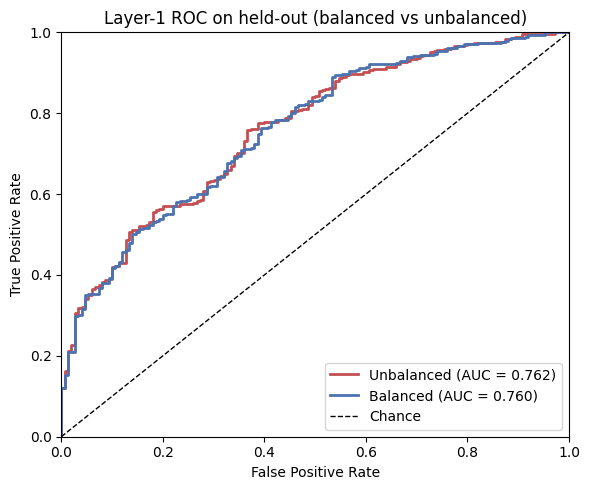

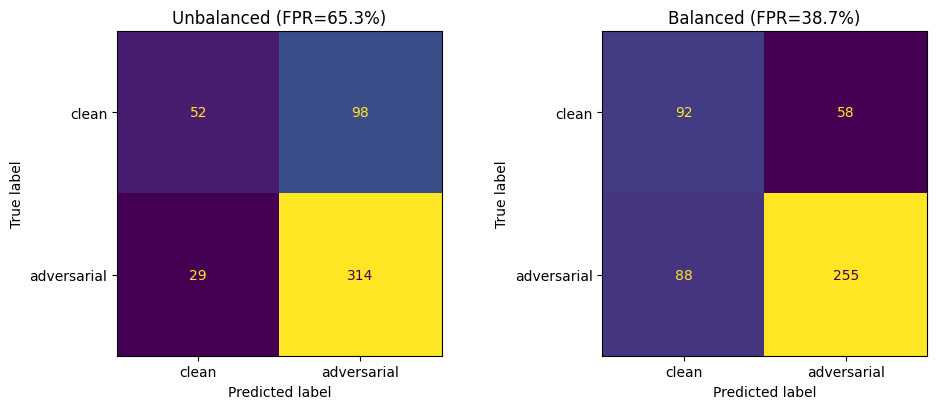

In [8]:
def evaluate_probe(probe, df, name):
    y_true = df["label"].values
    scores = np.array([probe.score(t) for t in df["text"]])
    y_pred = (scores >= probe.threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    fpr = ((y_pred == 1) & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)
    try:
        roc_auc = roc_auc_score(y_true, scores)
    except ValueError:
        roc_auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)
    print(f"[{name}] Acc={acc*100:.1f}%  Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  "
          f"F1={f1*100:.1f}%  FPR={fpr*100:.1f}%  AUC={roc_auc:.3f}")
    return {"scores": scores, "y_pred": y_pred, "cm": cm, "auc": roc_auc,
            "acc": acc, "prec": prec, "rec": rec, "f1": f1, "fpr": fpr}

print("=== Layer-1 held-out evaluation ===")
res_bal   = evaluate_probe(linear_probe, heldout_df, "balanced")
res_unbal = evaluate_probe(linear_probe_unbal, heldout_df, "unbalanced")

# Dual ROC
fig, ax = plt.subplots(figsize=(6, 5))
for res, label, color in [
    (res_unbal, "Unbalanced", "#C44E52"),
    (res_bal,   "Balanced",   "#4C72B0"),
]:
    fpr_c, tpr_c, _ = roc_curve(heldout_df["label"].values, res["scores"])
    ax.plot(fpr_c, tpr_c, color=color, lw=2,
            label=f"{label} (AUC = {res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Layer-1 ROC on held-out (balanced vs unbalanced)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "layer1_dual_roc.png"), dpi=150)
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, res, title in [
    (axes[0], res_unbal, f"Unbalanced (FPR={res_unbal['fpr']*100:.1f}%)"),
    (axes[1], res_bal,   f"Balanced (FPR={res_bal['fpr']*100:.1f}%)"),
]:
    ConfusionMatrixDisplay(res["cm"], display_labels=["clean", "adversarial"]).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "layer1_confusion_matrices.png"), dpi=150)
plt.show()

### Step 3c — Layer-2 held-out evaluation

In [9]:
l2_rows = []
for _, row in heldout_df.iterrows():
    res = fluency_gate.check(row["text"])
    l2_rows.append({
        "true_label": row["label"],
        "flagged": res["flagged"],
        "perplexity": res["perplexity"],
        "confidence": res["confidence"],
    })
l2_df = pd.DataFrame(l2_rows)

l2_adv = l2_df["true_label"] == 1
l2_clean = l2_df["true_label"] == 0
l2_interception = float(l2_df.loc[l2_adv, "flagged"].mean() * 100)
l2_fpr = float(l2_df.loc[l2_clean, "flagged"].mean() * 100)
print(f"Layer-2 standalone held-out interception : {l2_interception:.1f}%")
print(f"Layer-2 standalone held-out clean FPR    : {l2_fpr:.1f}%")
print(f"  (n_adv={l2_adv.sum()}, n_clean={l2_clean.sum()})")

Layer-2 standalone held-out interception : 19.8%
Layer-2 standalone held-out clean FPR    : 2.7%
  (n_adv=343, n_clean=150)


## Step 4 — CerberusFirewall LangGraph agent

**State contract (critical):**  
On every new check cycle the ingest node explicitly clears  
`layer1_score`, `layer1_flag`, `layer2_result`, `layer3_result`, `decision`.  
The decision node therefore only ever sees evidence produced in the *current* cycle.

Firewall compiled.


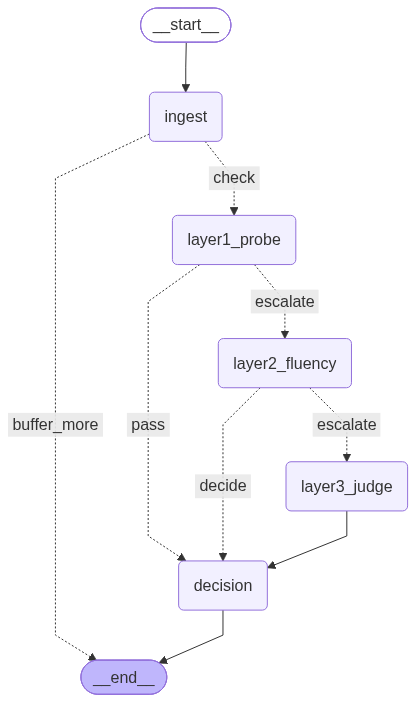

In [23]:
from typing import TypedDict, List, Dict, Any, Optional
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


class FirewallState(TypedDict, total=False):
    buffer: str
    new_chunk: str
    should_check: bool
    layer1_score: Optional[float]
    layer1_flag: bool
    layer2_result: Optional[Dict[str, Any]]
    layer3_result: Optional[Dict[str, Any]]
    decision: Optional[str]
    trace: Annotated[List[Dict[str, Any]], operator.add]


class CerberusFirewall:
    def __init__(self, linear_probe, fluency_gate, retrieval_memory, llm_judge,
                 chunk_trigger_chars=None):
        self.linear_probe = linear_probe
        self.fluency_gate = fluency_gate
        self.retrieval_memory = retrieval_memory
        self.llm_judge = llm_judge
        self.chunk_trigger_chars = chunk_trigger_chars or CONFIG["CHUNK_TRIGGER_CHARS"]
        self.checkpointer = InMemorySaver()
        self.graph = self._build_graph().compile(checkpointer=self.checkpointer)

    def _build_graph(self):
        g = StateGraph(FirewallState)
        g.add_node("ingest", self._ingest_node)
        g.add_node("layer1_probe", self._layer1_node)
        g.add_node("layer2_fluency", self._layer2_node)
        g.add_node("layer3_judge", self._layer3_node)
        g.add_node("decision", self._decision_node)
        g.add_edge(START, "ingest")
        g.add_conditional_edges(
            "ingest", self._route_after_ingest,
            {"buffer_more": END, "check": "layer1_probe"}
        )
        g.add_conditional_edges(
            "layer1_probe", self._route_after_layer1,
            {"pass": "decision", "escalate": "layer2_fluency"}
        )
        g.add_conditional_edges(
            "layer2_fluency", self._route_after_layer2,
            {"decide": "decision", "escalate": "layer3_judge"}
        )
        g.add_edge("layer3_judge", "decision")
        g.add_edge("decision", END)
        return g

    def _ingest_node(self, state):
        t0 = time.perf_counter()
        buffer = state.get("buffer", "") + state.get("new_chunk", "")
        should_check = len(buffer) >= self.chunk_trigger_chars
        entry = {
            "node": "ingest",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "buffer_len": len(buffer),
        }
        update = {"buffer": buffer, "should_check": should_check, "trace": [entry]}
        if should_check:
            # Clear ALL decision fields so later cycles cannot inherit stale evidence
            update["layer1_score"] = None
            update["layer1_flag"] = False
            update["layer2_result"] = None
            update["layer3_result"] = None
            update["decision"] = None
        return update

    def _layer1_node(self, state):
        t0 = time.perf_counter()
        score = self.linear_probe.score(text=state["buffer"])
        flag = score >= self.linear_probe.threshold
        entry = {
            "node": "layer1_probe",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "score": score, "flagged": flag,
        }
        return {"layer1_score": score, "layer1_flag": flag, "trace": [entry]}

    def _layer2_node(self, state):
        t0 = time.perf_counter()
        result = self.fluency_gate.check(state["buffer"])
        entry = {
            "node": "layer2_fluency",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            **result,
        }
        return {"layer2_result": result, "trace": [entry]}

    def _layer3_node(self, state):
        t0 = time.perf_counter()
        examples = self.retrieval_memory.retrieve(state["buffer"])
        result = self.llm_judge.judge(state["buffer"], retrieved_examples=examples)
        result["retrieved_examples"] = examples
        entry = {
            "node": "layer3_judge",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "verdict": result["verdict"],
            "raw_reply": result["raw_reply"],
        }
        return {"layer3_result": result, "trace": [entry]}

    def _decision_node(self, state):
        t0 = time.perf_counter()
        # Highest layer that actually ran in THIS cycle decides
        if state.get("layer3_result") is not None:
            decision = "block" if state["layer3_result"]["verdict"] == "UNSAFE" else "pass"
            source = "layer3_judge"
        elif state.get("layer2_result") is not None:
            decision = "block" if state["layer2_result"]["flagged"] else "pass"
            source = "layer2_fluency"
        else:
            # L1 alone never blocks; reaching here means L1 cleared the input
            decision = "pass"
            source = "layer1_probe"
        entry = {
            "node": "decision",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "decision": decision, "decided_by": source,
        }
        return {"decision": decision, "trace": [entry]}

    def _route_after_ingest(self, state):
        return "check" if state["should_check"] else "buffer_more"

    def _route_after_layer1(self, state):
        return "escalate" if state["layer1_flag"] else "pass"

    def _route_after_layer2(self, state):
        conf = state["layer2_result"]["confidence"]
        return "escalate" if conf < CONFIG["L2_ESCALATION_CONF"] else "decide"

    def process_stream(self, char_iterator, thread_id):
        config = {"configurable": {"thread_id": thread_id}}
        result = None
        for chunk in char_iterator:
            result = self.graph.invoke({"new_chunk": chunk}, config)
            if result.get("decision") == "block":
                break
        return result


firewall = CerberusFirewall(linear_probe, fluency_gate, retrieval_memory, llm_judge)

def char_stream(text, chunk_size=None):
    chunk_size = chunk_size or CONFIG["CHUNK_SIZE"]
    for i in range(0, len(text), chunk_size):
        yield text[i:i + chunk_size]

print("Firewall compiled.")


from IPython.display import Image, display

graph = firewall.graph.get_graph()

png_bytes = graph.draw_mermaid_png()

display(Image(png_bytes))

## Step 5 — End-to-End pipeline on every held-out example

In [21]:
e2e_rows = []
n_total = len(heldout_df)

for i, row in heldout_df.iterrows():
    t0 = time.perf_counter()
    result = firewall.process_stream(char_stream(row["text"]), thread_id=f"e2e_{i}")
    wall_ms = (time.perf_counter() - t0) * 1000

    if result is None:
        decision, reached_l3, layer3_verdict = "pass", False, None
        internal_sum, decided_by = 0.0, "never_triggered"
    else:
        decision = result.get("decision", "pass")
        reached_l3 = any(e["node"] == "layer3_judge" for e in result.get("trace", []))
        layer3_verdict = None
        if result.get("layer3_result"):
            layer3_verdict = result["layer3_result"].get("verdict")
        internal_sum = sum(e.get("latency_ms", 0) for e in result.get("trace", []))
        decided_by = next(
            (e.get("decided_by") for e in reversed(result.get("trace", []))
             if e.get("node") == "decision"),
            "unknown",
        )

    e2e_rows.append({
        "text": row["text"],
        "true_label": row["label"],
        "source": row["source"],
        "decision": decision,
        "reached_layer3": reached_l3,
        "layer3_verdict": layer3_verdict,
        "decided_by": decided_by,
        "wall_latency_ms": wall_ms,
        "internal_latency_ms": internal_sum,
    })
    if (i + 1) % 50 == 0 or (i + 1) == n_total:
        print(f"  ... {i+1}/{n_total} processed")

e2e_df = pd.DataFrame(e2e_rows)
print("\nDecision counts:")
print(e2e_df["decision"].value_counts())
print("\nDecided-by distribution:")
print(e2e_df["decided_by"].value_counts())

  ... 50/493 processed
  ... 100/493 processed
  ... 150/493 processed
  ... 200/493 processed
  ... 250/493 processed
  ... 300/493 processed
  ... 350/493 processed
  ... 400/493 processed
  ... 450/493 processed
  ... 493/493 processed

Decision counts:
decision
pass     292
block    201
Name: count, dtype: int64

Decided-by distribution:
decided_by
layer2_fluency    274
layer1_probe      133
layer3_judge       60
unknown            26
Name: count, dtype: int64


## Step 6 — Aggregate interception, clean FPR, confusion matrix

Aggregate interception rate (Req. 3): 51.9%  (178/343 adv blocked)
Full-pipeline clean FPR (Req. 4):     15.3%  (23/150 clean blocked)

Firewall-level confusion matrix (rows=true, cols=pred [pass=0, block=1]):
[[127  23]
 [165 178]]


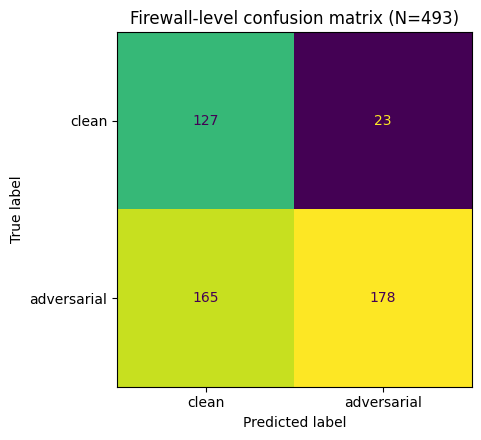

In [12]:
adv_mask = e2e_df["true_label"] == 1
clean_mask = e2e_df["true_label"] == 0

interception_rate = float((e2e_df.loc[adv_mask, "decision"] == "block").mean() * 100)
clean_fpr = float((e2e_df.loc[clean_mask, "decision"] == "block").mean() * 100)

print(f"Aggregate interception rate (Req. 3): {interception_rate:.1f}%  "
      f"({(e2e_df.loc[adv_mask,'decision']=='block').sum()}/{adv_mask.sum()} adv blocked)")
print(f"Full-pipeline clean FPR (Req. 4):     {clean_fpr:.1f}%  "
      f"({(e2e_df.loc[clean_mask,'decision']=='block').sum()}/{clean_mask.sum()} clean blocked)")

cm = confusion_matrix(
    e2e_df["true_label"],
    (e2e_df["decision"] == "block").astype(int)
)
print("\nFirewall-level confusion matrix (rows=true, cols=pred [pass=0, block=1]):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["clean", "adversarial"]).plot(
    ax=ax, colorbar=False
)
ax.set_title(f"Firewall-level confusion matrix (N={len(e2e_df)})")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "e2e_confusion_matrix.png"), dpi=150)
plt.show()

## Step 7 — Per-attack interception breakdown

Interception rate by source attack:
source
DeepWordBug    67.938931
TextFooler     42.148760
BERT-Attack    41.758242
Name: decision, dtype: float64


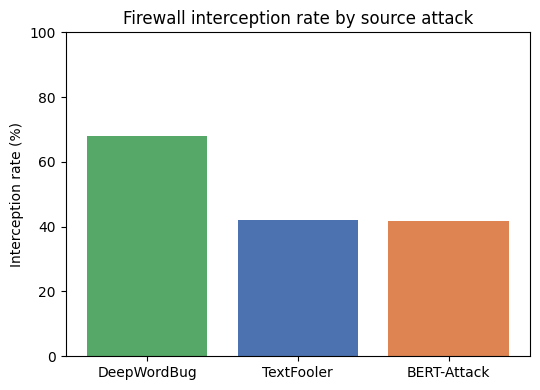

In [13]:
per_attack = (
    e2e_df[adv_mask]
    .groupby("source")["decision"]
    .apply(lambda d: (d == "block").mean() * 100)
    .sort_values(ascending=False)
)
print("Interception rate by source attack:")
print(per_attack)

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = ["#55A868", "#4C72B0", "#DD8452"]
ax.bar(per_attack.index, per_attack.values, color=colors[:len(per_attack)])
ax.set_ylabel("Interception rate (%)")
ax.set_title("Firewall interception rate by source attack")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "per_attack_breakdown.png"), dpi=150)
plt.show()

## Step 8 — Full Layer-3 evaluation

In [14]:
l3_subset = e2e_df[e2e_df["reached_layer3"]].copy()
print(f"{len(l3_subset)} / {len(e2e_df)} held-out examples "
      f"({100*len(l3_subset)/max(len(e2e_df),1):.1f}%) escalated to Layer 3.")

l3_accuracy = majority_baseline = None

if len(l3_subset) > 0:
    l3_subset["l3_correct"] = (
        ((l3_subset["true_label"] == 1) & (l3_subset["layer3_verdict"] == "UNSAFE")) |
        ((l3_subset["true_label"] == 0) & (l3_subset["layer3_verdict"] == "SAFE"))
    )
    l3_accuracy = float(l3_subset["l3_correct"].mean() * 100)
    maj = max(l3_subset["true_label"].mean(), 1 - l3_subset["true_label"].mean())
    majority_baseline = float(maj * 100)
    print(f"Layer-3 accuracy on its subset : {l3_accuracy:.1f}%")
    print(f"Majority-class baseline        : {majority_baseline:.1f}%")
    if l3_accuracy <= majority_baseline + 5:
        print("NOTE: Layer 3 is close to majority baseline — report this plainly.")
    print("\nLayer-3 crosstab (true_label vs verdict):")
    print(pd.crosstab(l3_subset["true_label"], l3_subset["layer3_verdict"], margins=True))
else:
    print("No examples reached Layer 3 — cannot evaluate in isolation.")

138 / 493 held-out examples (28.0%) escalated to Layer 3.
Layer-3 accuracy on its subset : 36.2%
Majority-class baseline        : 76.1%
NOTE: Layer 3 is close to majority baseline — report this plainly.

Layer-3 crosstab (true_label vs verdict):
layer3_verdict  SAFE  UNSAFE  All
true_label                       
0                  1       4    5
1                  6      49   55
All                7      53   60


## Step 9 — Retrieval leakage audit

In [24]:
leak_free_sims = leaky_sims = leaky_correct = None

if len(l3_subset) > 0:
    leaky_retrieval = RetrievalMemory(
        texts=pd.concat([calib_df["text"], heldout_df["text"]]).tolist(),
        labels=pd.concat([calib_df["label"], heldout_df["label"]]).tolist(),
    )
    leak_free_sims, leaky_sims, leaky_correct = [], [], []

    for _, row in l3_subset.iterrows():
        free_ex = retrieval_memory.retrieve(row["text"])
        leak_free_sims.append(free_ex[0]["similarity"] if free_ex else 0.0)

        leaky_ex = leaky_retrieval.retrieve(row["text"])
        leaky_sims.append(leaky_ex[0]["similarity"] if leaky_ex else 0.0)

        verdict = llm_judge.judge(row["text"], retrieved_examples=leaky_ex)["verdict"]
        correct = (
            (row["true_label"] == 1 and verdict == "UNSAFE") or
            (row["true_label"] == 0 and verdict == "SAFE")
        )
        leaky_correct.append(correct)

    print(f"Mean top-1 similarity — leakage-free : {np.mean(leak_free_sims):.3f}")
    print(f"Mean top-1 similarity — leaky        : {np.mean(leaky_sims):.3f}")
    print(f"Layer-3 accuracy — leakage-free      : {l3_accuracy:.1f}%")
    print(f"Layer-3 accuracy — leaky             : {100*np.mean(leaky_correct):.1f}%")
else:
    print("Skipped (no Layer-3 examples).")

Mean top-1 similarity — leakage-free : 0.775
Mean top-1 similarity — leaky        : 1.000
Layer-3 accuracy — leakage-free      : 36.2%
Layer-3 accuracy — leaky             : 30.4%


## Step 10 — End-to-end wall-clock latency P50 / P95 / P99

Wall-clock latency — median: 136.1 ms | P95: 507.8 ms | P99: 721.1 ms
(mean: 178.2 ms)
Internal node-sum mean (reference only): 141.5 ms


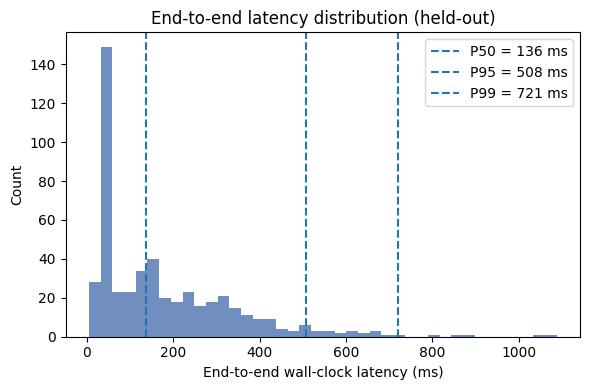

In [16]:
latencies = e2e_df["wall_latency_ms"].values
p50, p95, p99 = np.percentile(latencies, [50, 95, 99])
print(f"Wall-clock latency — median: {p50:.1f} ms | P95: {p95:.1f} ms | P99: {p99:.1f} ms")
print(f"(mean: {latencies.mean():.1f} ms)")
print(f"Internal node-sum mean (reference only): {e2e_df['internal_latency_ms'].mean():.1f} ms")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(latencies, bins=40, color="#4C72B0", alpha=0.8)
for p, val, lab in [(50, p50, "P50"), (95, p95, "P95"), (99, p99, "P99")]:
    ax.axvline(val, linestyle="--", label=f"{lab} = {val:.0f} ms")
ax.set_xlabel("End-to-end wall-clock latency (ms)")
ax.set_ylabel("Count")
ax.set_title("End-to-end latency distribution (held-out)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "latency_p95.png"), dpi=150)
plt.show()

## Step 11 — Layer ablation (short-circuit respecting)

                             Interception (%)  Clean FPR (%)
Configuration                                               
Layer 1 only (probe binary)              74.3           38.7
Layers 1+2 (short-circuit)               16.9            1.3
Full cascade (1+2+3)                     51.9           15.3


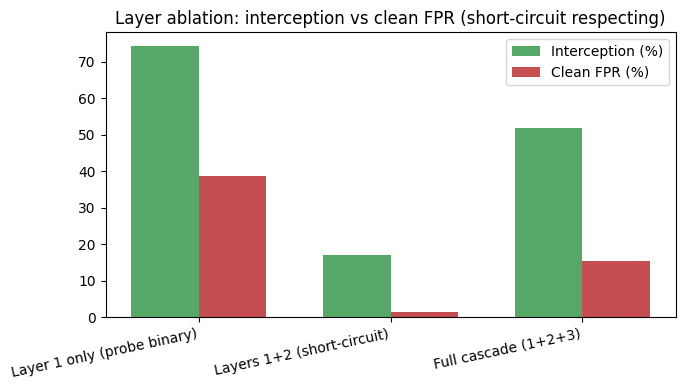

In [17]:
ablation_rows = []
for _, row in heldout_df.iterrows():
    score = linear_probe.score(text=row["text"])
    l1_flag = score >= linear_probe.threshold
    l1_only = "block" if l1_flag else "pass"

    if not l1_flag:
        l1_l2 = "pass"          # short-circuit identical to live cascade
    else:
        l2_res = fluency_gate.check(row["text"])
        l1_l2 = "block" if l2_res["flagged"] else "pass"

    ablation_rows.append({
        "true_label": row["label"],
        "l1_only": l1_only,
        "l1_l2": l1_l2,
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df["full_cascade"] = e2e_df["decision"].values

def interception_and_fpr(df, col):
    adv = df["true_label"] == 1
    clean = df["true_label"] == 0
    inter = (df.loc[adv, col] == "block").mean() * 100
    fpr = (df.loc[clean, col] == "block").mean() * 100
    return inter, fpr

summary = []
for col, label in [
    ("l1_only", "Layer 1 only (probe binary)"),
    ("l1_l2", "Layers 1+2 (short-circuit)"),
    ("full_cascade", "Full cascade (1+2+3)"),
]:
    inter, fpr = interception_and_fpr(ablation_df, col)
    summary.append({
        "Configuration": label,
        "Interception (%)": round(inter, 1),
        "Clean FPR (%)": round(fpr, 1),
    })

ablation_summary_df = pd.DataFrame(summary).set_index("Configuration")
print(ablation_summary_df)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ablation_summary_df))
w = 0.35
ax.bar(x - w/2, ablation_summary_df["Interception (%)"], w,
       label="Interception (%)", color="#55A868")
ax.bar(x + w/2, ablation_summary_df["Clean FPR (%)"], w,
       label="Clean FPR (%)", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(ablation_summary_df.index, rotation=12, ha="right")
ax.set_title("Layer ablation: interception vs clean FPR (short-circuit respecting)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "layer_ablation.png"), dpi=150)
plt.show()

## Step 12 — FINAL REPORT (paste into the paper)

In [18]:
print("=" * 72)
print("CERBERUS Final Unified Evaluation — FINAL REPORT")
print("=" * 72)
print(f"\n[Unified corpus] {len(corpus_df)} total "
      f"({len(calib_df)} calibration / {len(heldout_df)} held-out)")
print(f"[Req 3] Aggregate interception rate : {interception_rate:.1f}%")
print(f"[Req 4] Full-pipeline clean FPR     : {clean_fpr:.1f}%")
print(f"[Req 5] Confusion matrix:\n{cm}")
print(f"[Req 6] Per-attack interception:\n{per_attack}")
if l3_accuracy is not None:
    print(f"[Req 7] Layer-3 accuracy on subset  : {l3_accuracy:.1f}% "
          f"(n={len(l3_subset)}, majority baseline {majority_baseline:.1f}%)")
    if leak_free_sims is not None:
        print(f"[Req 8] Leak-free vs leaky top-1 sim : "
              f"{np.mean(leak_free_sims):.3f} vs {np.mean(leaky_sims):.3f}")
        print(f"[Req 8] Leak-free vs leaky L3 acc   : "
              f"{l3_accuracy:.1f}% vs {100*np.mean(leaky_correct):.1f}%")
print(f"[Req 9] Latency P50/P95/P99 (wall)  : {p50:.1f} / {p95:.1f} / {p99:.1f} ms")
print(f"[Req 10] Ablation:\n{ablation_summary_df}")
print(f"\n[Extra] L2 standalone held-out inter/FPR : {l2_interception:.1f}% / {l2_fpr:.1f}%")
print(f"[Extra] L1 balanced held-out AUC         : {res_bal['auc']:.3f}")
print(f"[Extra] L1 unbalanced held-out AUC       : {res_unbal['auc']:.3f}")
print("\nFigures saved under:", CONFIG["FIGURES_DIR"])
for f in [
    "layer1_dual_roc.png", "layer1_confusion_matrices.png",
    "e2e_confusion_matrix.png", "per_attack_breakdown.png",
    "latency_p95.png", "layer_ablation.png",
]:
    print(f"  - {f}")
print("\n" + "=" * 72)

CERBERUS Final Unified Evaluation — FINAL REPORT

[Unified corpus] 1643 total (1150 calibration / 493 held-out)
[Req 3] Aggregate interception rate : 51.9%
[Req 4] Full-pipeline clean FPR     : 15.3%
[Req 5] Confusion matrix:
[[127  23]
 [165 178]]
[Req 6] Per-attack interception:
source
DeepWordBug    67.938931
TextFooler     42.148760
BERT-Attack    41.758242
Name: decision, dtype: float64
[Req 7] Layer-3 accuracy on subset  : 36.2% (n=138, majority baseline 76.1%)
[Req 8] Leak-free vs leaky top-1 sim : 0.775 vs 1.000
[Req 8] Leak-free vs leaky L3 acc   : 36.2% vs 30.4%
[Req 9] Latency P50/P95/P99 (wall)  : 136.1 / 507.8 / 721.1 ms
[Req 10] Ablation:
                             Interception (%)  Clean FPR (%)
Configuration                                               
Layer 1 only (probe binary)              74.3           38.7
Layers 1+2 (short-circuit)               16.9            1.3
Full cascade (1+2+3)                     51.9           15.3

[Extra] L2 standalone held-out in

## Files for the paper

All figures are under `figures/`:
- `layer1_dual_roc.png`
- `layer1_confusion_matrices.png`
- `e2e_confusion_matrix.png`
- `per_attack_breakdown.png`
- `latency_p95.png`
- `layer_ablation.png`

Paste the Step-12 report block into the paper and replace any “results pending” notes.